# Compare growth rates of nude admixture mice to an additive model

This file generates Figure 3b in the text and the data for Supplementary Table 1.

It requires as input the file containing the tumor growth data, a config file, and the previously estimated exponential growth rates of the admixture data as input and will save the figure to the path if specified (change file path below as needed).

The code will estimate the growth rates of the additive model for each admixture. It will then create a plot comparing the growth rates estimated from the true data to the growth rates estimated from the additive model.

## Prep

Load required packages

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
from sklearn.metrics import mean_squared_error
from estimator import Estimator
from src import pyxfunc
from itertools import product

## Define data and user-input parameters

Define the data file, config file, save files, and admixture group names.

In [2]:
data_file = "data/growth_data_df.csv"
admix_result_path = "results/growth/"
config = "config_files/config_km.json"
fig_save_file = "figures/additive.svg" #"figures/add.svg" # Set to None to not save the figure
nude_groups = ["Grp. B1 nude (100% C1)", "Grp. B2 nude (80% C1; 20% C11)", "Grp. B3 nude (50% C1; 50% C11)", "Grp. B4 nude (20% C1; 80% C11)", "Grp. B5 nude (100% C11)"]
exclude = [456, 458, 461, 464, 471, 474, 478, 482, 483, 426, 428, 429, 430, 434, 437, 438, 442, 443, 451, 642, 662]
g_list = [round(0.1+0.001*i, 3) for i in range(round((.25-0.1)/0.001+1))]

Create an estimator object from the config file

In [3]:
es = Estimator(config)

Load the growth data

In [4]:
growth_df = pd.read_csv(data_file)
growth_df = growth_df[growth_df["group"].isin(nude_groups)]
growth_df = growth_df[~(growth_df["id"].isin(exclude))]
growth_df.loc[growth_df["group"]=="1C", "group"] = "Grp. A1 B6 (100% C1)"
growth_df.loc[growth_df["group"]=="2C", "group"] = "Grp. A2 B6 (80% C1; 20% C11)"
growth_df.loc[growth_df["group"]=="3C", "group"] = "Grp. A3 B6 (50% C1; 50% C11)"
growth_df.loc[growth_df["group"]=="4C", "group"] = "Grp. A4 B6 (20% C1; 80% C11)"
growth_df.loc[growth_df["group"]=="5C", "group"] = "Grp. A5 B6 (100% C11)"
es.growth_df = growth_df

In [5]:
def get_ratio(group):
    if "B1" in group: return 1
    if "A2" in group or "B2" in group: return 0.8
    if "A3" in group or "B3" in group: return 0.5
    if "A4" in group or "B4" in group: return 0.2
    if "B5" in group: return 0

## Methods to estimate the growth rates, either with a single exponential function or with additive exponentials

In [7]:
def get_grs():
    results = [[0]]*(len(growth_df["id"].unique())*len(g_list))
    idx = 0
    for mid in growth_df["id"].unique():
        for g_idx in range(len(g_list)):
            init = [growth_df[(growth_df["id"]==mid) & (growth_df["day"]==7)]["size"].iloc[0], 0, 0]
            end_time = max(growth_df[growth_df["id"] == mid]["day"])
            sol = pyxfunc.run(init[0], init[1], init[2], 7, end_time, np.inf, 
                                es.cutoff_0_raw, es.cutoff_0_percent, init[2],
                                g_list[g_idx], 0, 0, 0, 0, 0, 0, 0, 0)
            day_idxs = [(d-7)*100 for d in growth_df[growth_df["id"]==mid]["day"]]
            sizes = growth_df[growth_df["id"] == mid]["size"].tolist()
            err_win = pyxfunc.get_error(day_idxs, sizes, sol, 0, es.max_loser_subline_percent)
            results[idx] = [growth_df[(growth_df["id"]==mid)]["group"].tolist()[0], mid, g_list[g_idx], err_win[0], err_win[1]]
            idx += 1
    results = pd.DataFrame(results, columns=["group", "id", "g", "error", "winner"])
    results_best = results.groupby("id")[["group", "g", "error"]].apply(lambda x: x[x["error"]==x["error"].min()]).reset_index()
    results_best = results_best.drop("level_1", axis=1)
    return results_best

In [8]:
def get_additive_grs(g1s, g11s):
    results = []
    for group in range(0, 5):
        r = get_ratio(nude_groups[group])
        # print(r)
        for mid in growth_df[growth_df["group"]==nude_groups[group]]["id"].unique():
            days = growth_df[growth_df["id"] == mid].sort_values("day")["day"].unique()
            # start_size = growth_df[(growth_df["id"]==row["id"]) & (growth_df["day"]==7)]["size"]
            end_time = max(growth_df[growth_df["id"] == mid]["day"])
            init = [growth_df[(growth_df["id"]==mid) & (growth_df["day"]==7)]["size"].iloc[0], 0, 0]
            # print(init)
            # First, find the best-fitting pair of g1, g1
            mid_min = np.inf
            mid_g1_g11 = [0, 0]
            idx=0
            for g1_g11 in product(g1s, g11s):
                # print(g1_g11)
                # break
                sol_c1 = pyxfunc.run(init[0], init[1], init[2], 7, end_time, np.inf, 
                                    es.cutoff_0_raw, es.cutoff_0_percent, init[2],
                                    g1_g11[0], 0, 0, 0, 0, 0, 0, 0, 0)
                sol_c11 = pyxfunc.run(init[0], init[1], init[2], 7, end_time, np.inf, 
                                    es.cutoff_0_raw, es.cutoff_0_percent, init[2],
                                    g1_g11[1], 0, 0, 0, 0, 0, 0, 0, 0)
                
                sol = sol_c1
                sol_c1 = r*np.asarray(sol[0])
                sol_c11 = (1-r)*np.asarray(sol_c11[0])
                # print(sol_c1[-1])
                # print(sol_c11[-1])
                day_idxs = [(d-7)*100 for d in growth_df[growth_df["id"]==mid]["day"]]
                sizes = growth_df[growth_df["id"] == mid]["size"].tolist()
                sol[0] = sol_c1[day_idxs]
                sol[1] = sol_c11[day_idxs]
                mse = mean_squared_error(sol[0]+sol[1], sizes)
                # err_win = pyxfunc.pyerror(day_idxs, sizes, sol, 2, es.max_loser_subline_percent)
                # print(g1_g11, mse, sol[0], sol[1])
                if mse < mid_min:
                    mid_min = mse
                    mid_g1_g11 = g1_g11
            # print(mid_g1_g11)
            # break
            # Now, find the best fitting g to the curve of the best-fitting g1, g11
            mses = []
            idx=0
            for g_idx in range(len(g_list)):
                # print(g_list[g_idx])
                sol_c1 = pyxfunc.run(init[0], init[1], init[2], 7, end_time, np.inf, 
                                    es.cutoff_0_raw, es.cutoff_0_percent, init[2],
                                    mid_g1_g11[0], 0, 0, 0, 0, 0, 0, 0, 0)
                sol_c11 = pyxfunc.run(init[0], init[1], init[2], 7, end_time, np.inf, 
                                    es.cutoff_0_raw, es.cutoff_0_percent, init[2],
                                    mid_g1_g11[1], 0, 0, 0, 0, 0, 0, 0, 0)
                add_sol = r*np.asarray(sol_c1[0]) + (1-r)*np.asarray(sol_c11[0])
                
                g_sol = pyxfunc.run(init[0], init[1], init[2], 7, end_time, np.inf, 
                                    es.cutoff_0_raw, es.cutoff_0_percent, init[2],
                                    g_list[g_idx], 0, 0, 0, 0, 0, 0, 0, 0)
                mse = mean_squared_error(add_sol, np.asarray(g_sol[0])+np.asarray(g_sol[1]))
                results += [[growth_df[(growth_df["id"]==mid)]["group"].tolist()[0], mid, mid_g1_g11[0], mid_g1_g11[1], g_list[g_idx], mse]]
                idx += 1

    results = pd.DataFrame(results, columns=["group", "id", "g1", "g11", "g", "error"])
    results_best = results.groupby("id")[["group", "g1", "g11", "g", "error"]].apply(lambda x: x[x["error"]==x["error"].min()]).reset_index()
    results_best = results_best.drop("level_1", axis=1)
    return results_best

## Get growth rates with a single exponential function

In [9]:
results = get_grs()
results

In [11]:
g1s = results[results["group"] == "Grp. B1 nude (100% C1)"]["g"].tolist()
g11s = results[results["group"] == "Grp. B5 nude (100% C11)"]["g"].tolist()

## Get growth rates with additive exponential functions

In [ ]:
add_results = get_additive_grs(g1s, g11s)
add_results

## VAF data for plotting

In [15]:
vaf_c1 = [
    [[181.8696, 631.02672, 1701.777024], [0.899871622, 0.894625204, 0.904994015]],
    [[195.49296, 801.0121545, 1460.247552], [0.816024818, 0.895990759, 0.900951814]],
    [[309.0368375, 967.03805, 1048.831492], [0.709571688, 0.83452206, 0.827633684]]
]

vaf_c11 = [
    [[181.8696, 631.02672, 1701.777024], [0.056836006, 0.058616548, 0.046865762]],
    [[195.49296, 801.0121545, 1460.247552], [0.11771114, 0.058662079, 0.051429202]],
    [[309.0368375, 967.03805, 1048.831492], [0.260361516, 0.109984427, 0.133886601]]
]

## Plot results of single exponential model

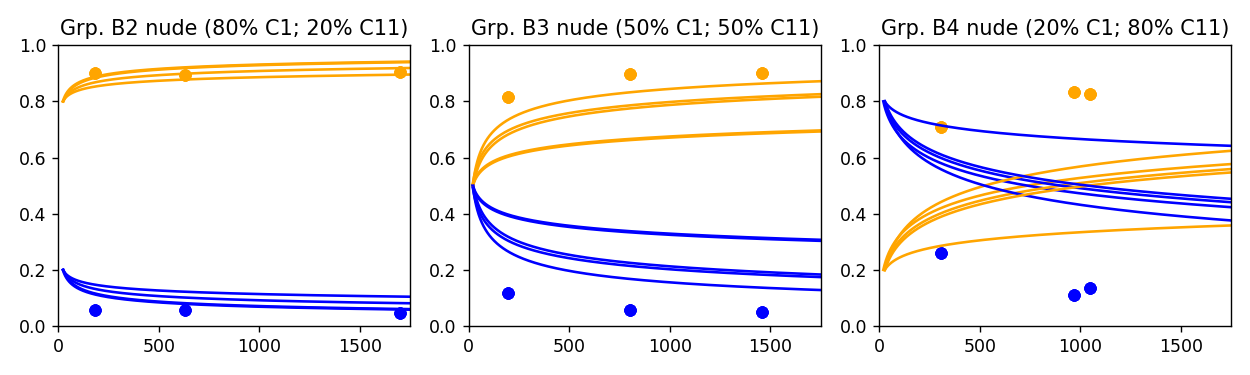

In [29]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharex=False, sharey=False, figsize=(10, 3))

for group in range(1, 4):
    r = get_ratio(nude_groups[group])
    max_time_id = growth_df[growth_df["day"] == growth_df["day"].max()]["id"].tolist()[0]
    days = growth_df[growth_df["id"] == max_time_id].sort_values("day")["day"].unique()
    for mid in growth_df[growth_df["group"]==nude_groups[group]]["id"].unique():
        end_time = max(days)
        init = [growth_df[(growth_df["id"]==mid) & (growth_df["day"]==7)]["size"].iloc[0], 0, 0]

        sol_c1 = pyxfunc.run(init[0]*r, init[1], init[2], 7, end_time, np.inf, 
                            es.cutoff_0_raw, es.cutoff_0_percent, init[2],
                            add_results[add_results["id"]==mid]["g1"].tolist()[0], 0, 0, 0, 0, 0, 0, 0, 0)
        sol_c11 = pyxfunc.run(init[0]*(1-r), init[1], init[2], 7, end_time, np.inf, 
                            es.cutoff_0_raw, es.cutoff_0_percent, init[2],
                            add_results[add_results["id"]==mid]["g11"].tolist()[0], 0, 0, 0, 0, 0, 0, 0, 0)
        
        sol_c1[0] = np.asarray(sol_c1[0])
        sol_c11[0] = np.asarray(sol_c11[0])
        axes[group-1].plot(sol_c1[0]+sol_c11[0], sol_c1[0]/(sol_c1[0]+sol_c11[0]), color="orange")
        axes[group-1].plot(sol_c1[0]+sol_c11[0], sol_c11[0]/(sol_c1[0]+sol_c11[0]), color="blue")
        axes[group-1].scatter(vaf_c1[group-1][0], vaf_c1[group-1][1], color="orange")
        axes[group-1].scatter(vaf_c11[group-1][0], vaf_c11[group-1][1], color="blue")
    
    axes[group-1].set_xlim((0, growth_df["size"].max()+50))
    axes[group-1].set_ylim((0, 1))
    axes[group-1].set_title(nude_groups[group])
plt.tight_layout()
if fig_save_file:
    plt.savefig(fig_save_file)
plt.show()

## Plot results of additive model

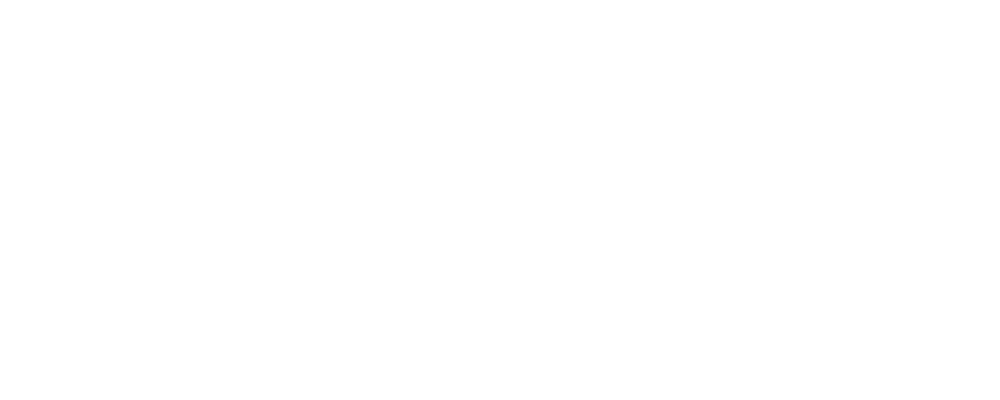

In [27]:
fig, axes = plt.subplots(nrows=1, ncols=3, sharex=False, sharey=True, figsize=(10, 4))
for group in range(1, 4):
    r = get_ratio(nude_groups[group])
    for mid in growth_df[growth_df["group"]==nude_groups[group]]["id"].unique():
        days = growth_df[growth_df["id"] == mid].sort_values("day")["day"].unique()
        end_time = max(growth_df[growth_df["id"] == mid]["day"])
        init = [growth_df[(growth_df["id"]==mid) & (growth_df["day"]==7)]["size"].tolist()[0], 0, 0]
        
        sol_c1 = pyxfunc.run(init[0]*r, init[1], init[2], 7, end_time, np.inf, 
                            es.cutoff_0_raw, es.cutoff_0_percent, init[2],
                            add_results[add_results["id"]==mid]["g1"].tolist()[0], 0, 0, 0, 0, 0, 0, 0, 0)
        sol_c11 = pyxfunc.run(init[0]*(1-r), init[1], init[2], 7, end_time, np.inf, 
                            es.cutoff_0_raw, es.cutoff_0_percent, init[2],
                            add_results[add_results["id"]==mid]["g11"].tolist()[0], 0, 0, 0, 0, 0, 0, 0, 0)
        
        axes[group-1].plot(growth_df[growth_df["id"] == mid]["day"], growth_df[growth_df["id"] == mid]["size"], color="black")
        
        axes[group-1].plot(sol_c1[3], sol_c1[0], color="orange")
        axes[group-1].plot(sol_c11[3], sol_c11[0], color="blue")
    axes[group-1].set_title(nude_groups[group])
plt.suptitle("Growth of additive model")
plt.tight_layout()
plt.show()